<a href="https://colab.research.google.com/github/muhammadnouman911/Autoencoder/blob/main/Autoencoder_CNn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

In [ ]:
# 1. Load and preprocess the MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [ ]:
# Reshape to (samples, 28, 28, 1) for CNN
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

In [ ]:
# 2. Build the CNN Autoencoder model
input_img = Input(shape=(28, 28, 1))

In [ ]:
# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)  # 28x28x32
x = MaxPooling2D((2, 2), padding='same')(x)                           # 14x14x32
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)          # 14x14x16
encoded = MaxPooling2D((2, 2), padding='same')(x)                     # 7x7x16

In [ ]:
# Decoder
x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)    # 7x7x16
x = UpSampling2D((2, 2))(x)                                           # 14x14x16
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)          # 14x14x32
x = UpSampling2D((2, 2))(x)                                           # 28x28x32
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)  # 28x28x1

In [ ]:
# Autoencoder Model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

In [ ]:
# 3. Train the model
autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.2345 - val_loss: 0.0809
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0799 - val_loss: 0.0751
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0750 - val_loss: 0.0723
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0726 - val_loss: 0.0711
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0716 - val_loss: 0.0704
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0708 - val_loss: 0.0697
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0701 - val_loss: 0.0692
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0697 - val_loss: 0.0688
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0693 - val_loss: 0.0685
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0690 - val_loss: 0.0682
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0687 - val_loss: 0.0680
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/st

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


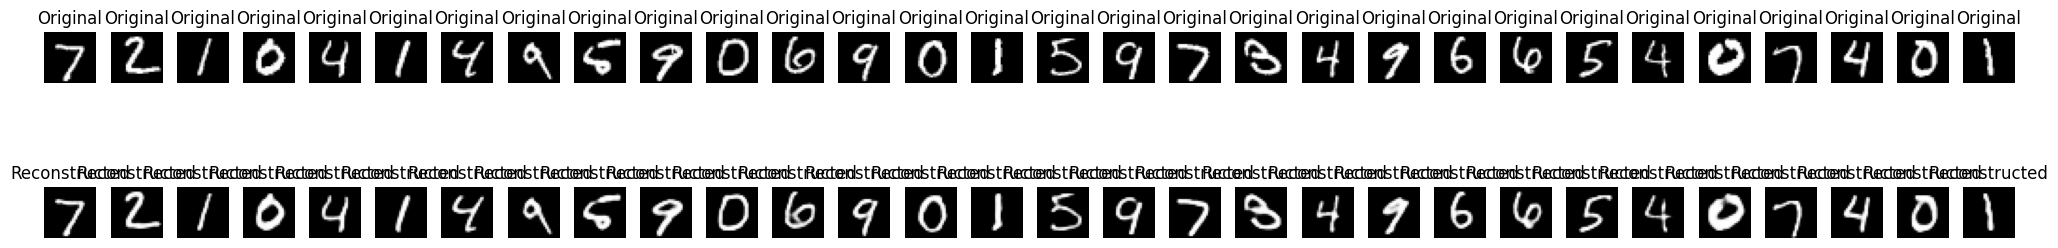

In [ ]:
# Predict reconstructed images
decoded_imgs = autoencoder.predict(x_test)

# Show 10 original and reconstructed images
n = 30
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")

    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()
